# Variational Autoencoder (VAE) Tutorial

**A beginner-friendly, step-by-step guide to understanding and implementing a VAE.**

Reference: [Lilian Weng - From Autoencoder to Beta-VAE](https://lilianweng.github.io/posts/2018-08-12-vae/)

---

## Table of Contents
1. [What Problem Does a VAE Solve?](#1-what-problem-does-a-vae-solve)
2. [From Autoencoder to VAE](#2-from-autoencoder-to-vae)
3. [The Math Behind VAE (ELBO)](#3-the-math-behind-vae-elbo)
4. [The Reparameterization Trick](#4-the-reparameterization-trick)
5. [Architecture Overview](#5-architecture-overview)
6. [Implementation](#6-implementation)
7. [Training](#7-training)
8. [Visualizing Results](#8-visualizing-results)
9. [Exploring the Latent Space](#9-exploring-the-latent-space)

<a id="1-what-problem-does-a-vae-solve"></a>
## 1. What Problem Does a VAE Solve?

Imagine you have thousands of cartoon face images. You want to:
- **Generate new faces** that look realistic but don't exist in the dataset
- **Learn a compact representation** (latent code) that captures meaningful features like hair color, face shape, etc.

A **Variational Autoencoder (VAE)** does both! It learns to compress images into a small latent vector `z`, and then decompress `z` back into images. Unlike a regular autoencoder, the VAE's latent space is **structured** -- you can sample random points from it and decode them into realistic images.

![VAE Overview](diagrams/vae_overview.png)

The encoder compresses the image into a small vector z. The decoder reconstructs the image from z. New images are generated by sampling z ~ N(0, I) and decoding.

<a id="2-from-autoencoder-to-vae"></a>
## 2. From Autoencoder to VAE

### Regular Autoencoder (AE)
A regular autoencoder maps each input to a **single point** in latent space. This works for reconstruction, but the latent space has "holes" -- if you sample a random point, the decoder may produce garbage.

### Variational Autoencoder (VAE)
A VAE fixes this by mapping each input to a **probability distribution** (a Gaussian) in latent space. This forces the latent space to be smooth and continuous.

![AE vs VAE](diagrams/ae_vs_vae.png)

**Key insight**: Because the VAE's latent space is smooth, nearby points decode to similar images. This means we can:
- Interpolate between two faces smoothly
- Sample random z values and get plausible faces

<a id="3-the-math-behind-vae-elbo"></a>
## 3. The Math Behind VAE (ELBO)

Don't worry -- we'll break this down piece by piece!

### The Goal
We want to maximize the probability of our data: $\log p(x)$. But this is intractable (we can't compute it directly). Instead, we maximize a **lower bound** called the **ELBO** (Evidence Lower BOund):

$$\log p(x) \geq \underbrace{\mathbb{E}_{q(z|x)}[\log p(x|z)]}_{\text{Reconstruction term}} - \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{KL divergence term}} = \text{ELBO}$$

### What Does Each Term Mean?

| Term | What it does | Intuition |
|------|-------------|-----------|
| $\mathbb{E}_{q(z|x)}[\log p(x|z)]$ | **Reconstruction loss** | "How well can the decoder reconstruct the input?" |
| $D_{KL}(q(z|x) \| p(z))$ | **KL divergence** | "How close is the learned distribution to the prior N(0,I)?" |

### In Practice

- **Reconstruction loss** = MSE between input and output (per sample, summed over pixels)
- **KL divergence** has a closed-form solution when both distributions are Gaussian:

$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

where $d$ is the latent dimension, $\mu_j$ and $\sigma_j^2$ are the encoder outputs.

### The Loss We Minimize

$$\mathcal{L} = \underbrace{\|x - \hat{x}\|^2}_{\text{MSE reconstruction}} + \underbrace{\beta \cdot D_{KL}}_{\text{KL regularizer}}$$

- When $\beta = 1$: standard VAE
- When $\beta > 1$: **beta-VAE** (stronger disentanglement, but blurrier reconstructions)

<a id="4-the-reparameterization-trick"></a>
## 4. The Reparameterization Trick

### The Problem
During training, we need to sample $z \sim \mathcal{N}(\mu, \sigma^2)$. But **sampling is not differentiable** -- we can't backpropagate gradients through a random operation!

### The Solution
Instead of sampling $z$ directly from $\mathcal{N}(\mu, \sigma^2)$, we:
1. Sample $\epsilon \sim \mathcal{N}(0, I)$ (this has no learnable parameters)
2. Compute $z = \mu + \sigma \odot \epsilon$

Now $z$ is a **deterministic function** of $\mu$, $\sigma$, and $\epsilon$, so gradients can flow through $\mu$ and $\sigma$ back to the encoder!

![Reparameterization Trick](diagrams/reparam_trick.png)

### In code:
```python
def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)   # sigma = exp(0.5 * log(sigma^2))
    eps = torch.randn_like(std)       # epsilon ~ N(0, I)
    return mu + std * eps             # z = mu + sigma * epsilon
```

**Why `log_var` instead of `sigma`?** The encoder outputs $\log \sigma^2$ (log-variance) instead of $\sigma$ directly because:
- $\log \sigma^2$ can be any real number (no need to enforce positivity)
- It's numerically more stable

<a id="5-architecture-overview"></a>
## 5. Architecture Overview

Our VAE uses convolutional layers for 64x64 RGB cartoon face images. The encoder progressively downsamples with stride-2 convolutions, while the decoder mirrors it with transposed convolutions.

![VAE Architecture](diagrams/architecture.png)

**Encoder**: 4 Conv2d layers (stride=2) shrink spatial dims 64 -> 32 -> 16 -> 8 -> 4, then two linear heads output $\mu$ and $\log \sigma^2$ (each 128-dim).

**Decoder**: Linear layer reshapes z to 256x4x4 feature map, then 4 ConvTranspose2d layers upsample back to 3x64x64. Final Tanh activation outputs values in [-1, 1].

<a id="6-implementation"></a>
## 6. Implementation

Let's build the VAE step by step. First, imports and setup.

In [1]:
import sys
from pathlib import Path

import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Hyperparameters
IMG_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 128
LR = 1e-3
NUM_EPOCHS = 50
KL_WEIGHT = 1.0      # beta=1 for standard VAE; increase for beta-VAE
SAVE_EVERY = 10

# Paths
DATA_ROOT = Path("../dataset/data/cartoonset100k/cartoonset100k").resolve()
SAVE_DIR = Path(".").resolve()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 6.1 Data Loading

We load 64x64 cartoon face PNGs, normalize pixel values to [-1, 1] (matching the decoder's Tanh output range).

Dataset size: 100000 images
Batches per epoch: 1562


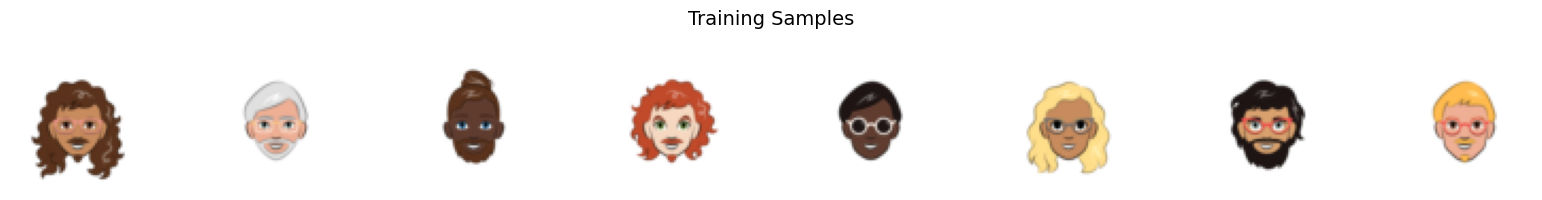

In [2]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(IMG_SIZE),
    torchvision.transforms.CenterCrop(IMG_SIZE),
    torchvision.transforms.ToTensor(),                        # [0, 1]
    torchvision.transforms.Normalize([0.5]*3, [0.5]*3),      # [-1, 1]
])

dataset = torchvision.datasets.ImageFolder(
    root=str(DATA_ROOT),
    loader=lambda path: Image.open(path).convert("RGB"),
    is_valid_file=lambda x: x.endswith(".png"),
    transform=transform,
)
loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2,
)

print(f"Dataset size: {len(dataset)} images")
print(f"Batches per epoch: {len(loader)}")

# Visualize a few training samples
sample_batch, _ = next(iter(loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = sample_batch[i] * 0.5 + 0.5  # [-1,1] -> [0,1]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 The Encoder

The encoder takes a 64x64 RGB image and outputs two vectors: **mu** ($\mu$) and **log_var** ($\log \sigma^2$). Together they define a Gaussian distribution $q(z|x) = \mathcal{N}(\mu, \sigma^2 I)$ in latent space.

We use 4 convolutional layers, each halving the spatial dimensions: 64 -> 32 -> 16 -> 8 -> 4. Then we flatten and project to the latent dimension.

In [3]:
class Encoder(nn.Module):
    """Maps input x to latent distribution parameters (mu, log_var)."""

    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()
        # Each Conv2d with stride=2 halves spatial dims: 64->32->16->8->4
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, 2, 1),   # [B, 32, 32, 32]
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),             # [B, 64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),            # [B, 128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),           # [B, 256, 4, 4]
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        # Two separate heads: one for mu, one for log_var
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_log_var = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)       # [B, 4096]
        return self.fc_mu(h), self.fc_log_var(h)

# Quick test
enc = Encoder(latent_dim=LATENT_DIM)
test_input = torch.randn(2, 3, 64, 64)
mu, log_var = enc(test_input)
print(f"Encoder output shapes:  mu={mu.shape}, log_var={log_var.shape}")

Encoder output shapes:  mu=torch.Size([2, 128]), log_var=torch.Size([2, 128])


### 6.3 The Decoder

The decoder is the mirror image of the encoder. It takes a latent vector `z` and reconstructs the image using transposed convolutions (which upsample spatial dimensions).

The final activation is **Tanh**, outputting values in [-1, 1] to match our normalized input range.

In [4]:
class Decoder(nn.Module):
    """Maps latent z back to image space."""

    def __init__(self, latent_dim=128, out_channels=3):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        # Each ConvTranspose2d with stride=2 doubles spatial dims: 4->8->16->32->64
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # [B, 128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # [B, 64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # [B, 32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, out_channels, 4, 2, 1),  # [B, 3, 64, 64]
            nn.Tanh(),  # output in [-1, 1]
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)  # reshape to feature map
        return self.deconv(h)

# Quick test
dec = Decoder(latent_dim=LATENT_DIM)
test_z = torch.randn(2, LATENT_DIM)
output = dec(test_z)
print(f"Decoder output shape: {output.shape}")
print(f"Output range: [{output.min().item():.2f}, {output.max().item():.2f}]")

Decoder output shape: torch.Size([2, 3, 64, 64])
Output range: [-1.00, 0.99]


### 6.4 Putting It Together: The VAE

The VAE combines encoder + reparameterization + decoder, and defines the ELBO loss.

In [5]:
class VAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(in_channels, latent_dim)
        self.decoder = Decoder(latent_dim, in_channels)

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick: z = mu + sigma * epsilon
        This allows gradients to flow through mu and log_var.
        """
        std = torch.exp(0.5 * log_var)   # sigma = sqrt(exp(log_var))
        eps = torch.randn_like(std)       # epsilon ~ N(0, I)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)           # encode to distribution params
        z = self.reparameterize(mu, log_var)     # sample z
        x_recon = self.decoder(z)                # decode back to image
        return x_recon, mu, log_var

    def sample(self, n, device):
        """Generate new images by sampling z from the prior N(0, I)."""
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)

    @staticmethod
    def loss(x, x_recon, mu, log_var):
        """
        ELBO loss = Reconstruction loss + KL divergence

        Reconstruction: MSE summed over pixels, averaged over batch
        KL divergence:  closed-form for Gaussian q(z|x) vs. prior N(0,I)
        """
        recon_loss = nn.functional.mse_loss(x_recon, x, reduction='sum') / x.size(0)
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
        return recon_loss, kl_loss

# Create model and count parameters
model = VAE(in_channels=3, latent_dim=LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"VAE parameters: {n_params:,}")

# Verify forward pass
with torch.no_grad():
    x_test = torch.randn(2, 3, 64, 64, device=device)
    x_recon, mu, log_var = model(x_test)
    recon_loss, kl_loss = VAE.loss(x_test, x_recon, mu, log_var)
    print(f"Forward pass OK:  recon_loss={recon_loss:.2f}, kl_loss={kl_loss:.2f}")

/home/CORP/shuai.lou/miniconda3/envs/aigc-examples/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


VAE parameters: 2,958,595
Forward pass OK:  recon_loss=14956.68, kl_loss=14.84


### 6.5 Understanding the Loss Function

Let's visualize what the KL divergence term does. It penalizes the encoder for producing distributions that are far from the standard normal $\mathcal{N}(0, I)$.

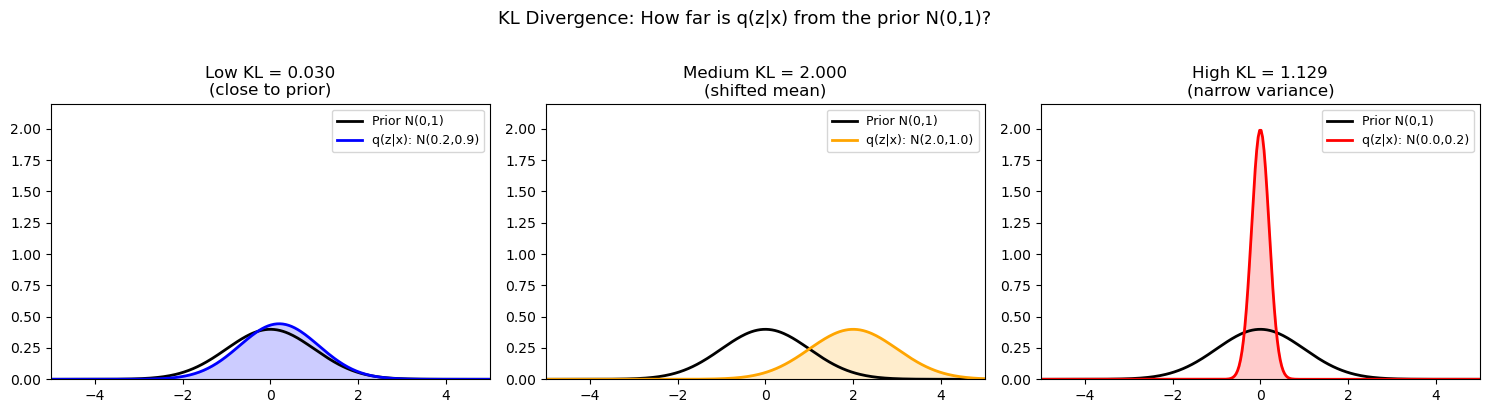

In [6]:
# Visualize KL divergence for different mu and sigma values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_range = np.linspace(-5, 5, 300)

# Helper: plot Gaussian
def plot_gaussian(ax, mu, sigma, label, color):
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma) ** 2)
    ax.plot(x_range, y, label=label, color=color, linewidth=2)

# Prior N(0,1) shown in all panels
for ax in axes:
    plot_gaussian(ax, 0, 1, "Prior N(0,1)", "black")

# Case 1: q close to prior (low KL)
mu1, sigma1 = 0.2, 0.9
kl1 = -0.5 * (1 + np.log(sigma1**2) - mu1**2 - sigma1**2)
plot_gaussian(axes[0], mu1, sigma1, f"q(z|x): N({mu1},{sigma1})", "blue")
axes[0].set_title(f"Low KL = {kl1:.3f}\n(close to prior)")
axes[0].fill_between(x_range,
    (1/(sigma1*np.sqrt(2*np.pi)))*np.exp(-0.5*((x_range-mu1)/sigma1)**2),
    alpha=0.2, color="blue")

# Case 2: shifted mean (medium KL)
mu2, sigma2 = 2.0, 1.0
kl2 = -0.5 * (1 + np.log(sigma2**2) - mu2**2 - sigma2**2)
plot_gaussian(axes[1], mu2, sigma2, f"q(z|x): N({mu2},{sigma2})", "orange")
axes[1].set_title(f"Medium KL = {kl2:.3f}\n(shifted mean)")
axes[1].fill_between(x_range,
    (1/(sigma2*np.sqrt(2*np.pi)))*np.exp(-0.5*((x_range-mu2)/sigma2)**2),
    alpha=0.2, color="orange")

# Case 3: narrow variance (high KL)
mu3, sigma3 = 0.0, 0.2
kl3 = -0.5 * (1 + np.log(sigma3**2) - mu3**2 - sigma3**2)
plot_gaussian(axes[2], mu3, sigma3, f"q(z|x): N({mu3},{sigma3})", "red")
axes[2].set_title(f"High KL = {kl3:.3f}\n(narrow variance)")
axes[2].fill_between(x_range,
    (1/(sigma3*np.sqrt(2*np.pi)))*np.exp(-0.5*((x_range-mu3)/sigma3)**2),
    alpha=0.2, color="red")

for ax in axes:
    ax.legend(fontsize=9)
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 2.2)

fig.suptitle("KL Divergence: How far is q(z|x) from the prior N(0,1)?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<a id="7-training"></a>
## 7. Training

Now let's train the VAE! The training loop:
1. Pass image through encoder to get $\mu$, $\log \sigma^2$
2. Sample $z$ using the reparameterization trick
3. Pass $z$ through decoder to get reconstruction $\hat{x}$
4. Compute loss = reconstruction loss + $\beta \times$ KL divergence
5. Backpropagate and update weights

We track both loss components separately to monitor the reconstruction-regularization tradeoff.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Track losses for plotting
history = {"recon": [], "kl": [], "total": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_recon, epoch_kl, count = 0.0, 0.0, 0

    for bidx, (x, _) in enumerate(loader):
        x = x.to(device)

        # Forward pass
        x_recon, mu, log_var = model(x)

        # Compute ELBO loss
        recon_loss, kl_loss = VAE.loss(x, x_recon, mu, log_var)
        loss = recon_loss + KL_WEIGHT * kl_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()
        count += 1

    scheduler.step()

    # Record epoch averages
    avg_recon = epoch_recon / count
    avg_kl = epoch_kl / count
    avg_total = avg_recon + KL_WEIGHT * avg_kl
    history["recon"].append(avg_recon)
    history["kl"].append(avg_kl)
    history["total"].append(avg_total)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  recon={avg_recon:.4f}  kl={avg_kl:.4f}  total={avg_total:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

    if epoch % SAVE_EVERY == 0:
        torch.save(model.state_dict(), SAVE_DIR / f"model_epoch_{epoch}.pth")

print("Training complete!")
torch.save(model.state_dict(), SAVE_DIR / "model_final.pth")

KeyboardInterrupt: 

### 7.1 Training Curves

Let's plot the loss components over time. You should see:
- **Reconstruction loss** decreasing as the model learns to reconstruct images
- **KL loss** initially increasing (as the encoder learns to use the latent space), then stabilizing
- The model balances both objectives -- this is the **reconstruction vs. regularization tradeoff**

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history["recon"]) + 1)

axes[0].plot(epochs_range, history["recon"], "b-", linewidth=2)
axes[0].set_title("Reconstruction Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["kl"], "r-", linewidth=2)
axes[1].set_title("KL Divergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history["total"], "g-", linewidth=2)
axes[2].set_title("Total Loss (Recon + KL)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id="8-visualizing-results"></a>
## 8. Visualizing Results

### 8.1 Reconstructions
Let's see how well the VAE reconstructs training images. Top row = original, bottom row = reconstruction.

In [ ]:
def to_image(tensor):
    """Convert [-1,1] tensor to [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

model.eval()
n_show = 8
x_batch, _ = next(iter(loader))
x_batch = x_batch[:n_show].to(device)

with torch.no_grad():
    x_recon, _, _ = model(x_batch)

fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
for i in range(n_show):
    # Original
    axes[0, i].imshow(to_image(x_batch[i]).cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", fontsize=11)

    # Reconstruction
    axes[1, i].imshow(to_image(x_recon[i]).cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=11)

fig.suptitle("Input vs. Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()

### 8.2 Random Samples from the Prior

The key advantage of a VAE over a regular autoencoder: we can **generate brand new images** by sampling $z \sim \mathcal{N}(0, I)$ and decoding.

In [ ]:
model.eval()
with torch.no_grad():
    samples = model.sample(16, device)
    samples = to_image(samples).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("Random Samples from z ~ N(0, I)", fontsize=14)
plt.tight_layout()
plt.show()

<a id="9-exploring-the-latent-space"></a>
## 9. Exploring the Latent Space

### 9.1 Latent Space Interpolation

One of the most fascinating properties of VAEs: **smooth interpolation**. We can take two images, encode them to latent vectors $z_A$ and $z_B$, and linearly interpolate between them. The decoded intermediate points should transition smoothly.

In [ ]:
model.eval()
n_steps = 10

# Get two different images
x_batch, _ = next(iter(loader))
x_a = x_batch[0:1].to(device)
x_b = x_batch[1:2].to(device)

with torch.no_grad():
    # Encode both images (use mu as the latent representation, no sampling noise)
    mu_a, _ = model.encoder(x_a)
    mu_b, _ = model.encoder(x_b)

    # Linear interpolation in latent space
    alphas = torch.linspace(0, 1, n_steps, device=device).unsqueeze(1)
    z_interp = mu_a * (1 - alphas) + mu_b * alphas  # [n_steps, latent_dim]

    # Decode all interpolated latent vectors
    x_interp = model.decoder(z_interp)
    x_interp = to_image(x_interp).cpu()

fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_interp[i].permute(1, 2, 0).numpy())
    ax.axis("off")
    if i == 0:
        ax.set_title("Image A", fontsize=10)
    elif i == n_steps - 1:
        ax.set_title("Image B", fontsize=10)

fig.suptitle("Latent Space Interpolation: A --> B", fontsize=14)
plt.tight_layout()
plt.show()

### 9.2 Latent Dimension Manipulation

We can explore what individual latent dimensions control by varying one dimension at a time while keeping others fixed. This reveals the "features" the VAE has learned.

In [ ]:
model.eval()
n_dims_to_show = 5   # number of latent dimensions to explore
n_values = 8         # number of values per dimension
value_range = (-3, 3)

# Start from a base latent vector (mean of some encoded images)
x_batch, _ = next(iter(loader))
with torch.no_grad():
    mu_batch, _ = model.encoder(x_batch[:32].to(device))
    z_base = mu_batch.mean(dim=0, keepdim=True)  # [1, latent_dim]

fig, axes = plt.subplots(n_dims_to_show, n_values, figsize=(2 * n_values, 2 * n_dims_to_show))
values = torch.linspace(value_range[0], value_range[1], n_values)

with torch.no_grad():
    for row, dim_idx in enumerate(range(n_dims_to_show)):
        for col, val in enumerate(values):
            z = z_base.clone()
            z[0, dim_idx] = val
            img = model.decoder(z)
            img = to_image(img[0]).cpu().permute(1, 2, 0).numpy()
            axes[row, col].imshow(img)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_ylabel(f"dim {dim_idx}", fontsize=11, rotation=0, labelpad=40)
            if row == 0:
                axes[row, col].set_title(f"z={val:.1f}", fontsize=10)

fig.suptitle("Varying Individual Latent Dimensions", fontsize=14)
plt.tight_layout()
plt.show()

### 9.3 Latent Space Visualization with t-SNE

Let's visualize the 128-dimensional latent space by projecting it down to 2D using t-SNE. If the VAE has learned a good latent space, similar-looking images should cluster together.

In [ ]:
from sklearn.manifold import TSNE

model.eval()
n_samples = 1000

# Encode a batch of images
all_mu = []
with torch.no_grad():
    for x, _ in loader:
        mu, _ = model.encoder(x.to(device))
        all_mu.append(mu.cpu())
        if sum(m.shape[0] for m in all_mu) >= n_samples:
            break

all_mu = torch.cat(all_mu)[:n_samples].numpy()

# t-SNE projection to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_2d = tsne.fit_transform(all_mu)

plt.figure(figsize=(8, 8))
plt.scatter(z_2d[:, 0], z_2d[:, 1], s=5, alpha=0.5, c=np.arange(n_samples), cmap="viridis")
plt.title("t-SNE of VAE Latent Space (mu vectors)", fontsize=14)
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.colorbar(label="Sample index")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

![VAE Training Summary](diagrams/summary.png)

### Key Takeaways

- **VAEs are generative models**: they learn to generate new data, not just reconstruct it
- **The ELBO loss** has two parts: reconstruction quality + latent space regularization
- **The reparameterization trick** makes it possible to backpropagate through sampling
- **KL divergence** keeps the latent space organized and close to $\mathcal{N}(0, I)$
- **Smooth latent space** enables interpolation between images and meaningful dimension manipulation
- **beta-VAE** (KL_WEIGHT > 1) encourages more disentangled latent representations at the cost of reconstruction quality

### Further Reading
- [Lilian Weng: From Autoencoder to Beta-VAE](https://lilianweng.github.io/posts/2018-08-12-vae/)
- [Kingma & Welling (2014): Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) -- the original VAE paper
- [Higgins et al. (2017): beta-VAE](https://openreview.net/forum?id=Sy2fzU9gl) -- disentangled representations